# Data Importing

In [1]:
#Import The required Python libraries.
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from skimage import io, transform
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from keras.callbacks import ModelCheckpoint, EarlyStopping,CSVLogger,ProgbarLogger
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.regularizers import l2


**Changable_Parameter**

In [7]:
#here image size is 256x256
IMAGE_SIZE = 75
#every time process 32 images (61x31)~1951
BATCH_SIZE = 32
#how many color have in these pictures
CHANNELS = 3
#80x25~1951
EPOCHS = 50
NUM_CLASSES = 7
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
patience=20
data_dir ="E:\\Capstone\\Dataset\\Gray_Img\\images"

model_name="ConvNeXtTiny" 

In [9]:
import tensorflow as tf



# Define image parameters
img_height = IMAGE_SIZE
img_width = img_height
batch_size = BATCH_SIZE

# Define data augmentation parameters
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 , # 20% of the data will be used for validation
    rotation_range=60,  # Rotate images randomly up to 20 degrees
    # Zoom range [1-zoom_range, 1+zoom_range]
    #horizontal_flip=True,  # Flip images horizontally
    #vertical_flip=True  # Flip images vertically
     # Strategy used for filling in newly created pixels
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
    # fill_mode='nearest',
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Update for multi-class classification
    subset='training'  # specify that this generator will be used for training data
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Update for multi-class classification
    subset='validation'  # specify that this generator will be used for validation data
)


Found 16126 images belonging to 7 classes.
Found 4031 images belonging to 7 classes.


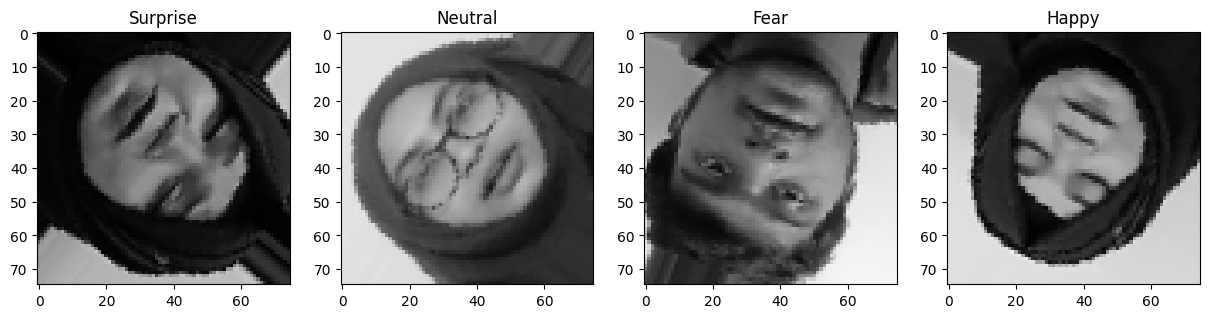

In [10]:
images, labels = next(train_generator)

# Plot four random images from the batch
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    # Generate a random index
    random_index = np.random.randint(0, BATCH_SIZE)
    
    # Plot the image
    axes[i].imshow(images[random_index])
    
    # Get the corresponding label
    label = labels[random_index]
    
    # Set the title as the class name
    class_name = train_generator.class_indices
    axes[i].set_title(list(class_name.keys())[np.argmax(label)])

plt.show()

# Building model

In [12]:
from tensorflow.keras.applications import EfficientNetV2B0,ResNet50,InceptionV3,NASNetMobile,EfficientNetV2B1
from keras.applications.convnext import ConvNeXtTiny

model= ConvNeXtTiny(weights = 'imagenet', 
                 include_top = False, 
                 input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3),
                 include_preprocessing=True
                 )

# Here we freeze the last 4 layers 
# Layers are set to trainable as True by default
for layer in model.layers:
    layer.trainable = False
    
# Let's print our layers 
# for (i,layer) in enumerate(model.layers):
#     print(str(i) + " "+ layer.__class__.__name__, layer.trainable)

111650432/111650432 [==============================] - 195s 2us/step


In [13]:
model.summary()

Model: "convnext_tiny"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 75, 75, 3)]          0         []                            
                                                                                                  
 convnext_tiny_prestem_norm  (None, 75, 75, 3)            0         ['input_2[0][0]']             
 alization (Normalization)                                                                        
                                                                                                  
 convnext_tiny_stem (Sequen  (None, 18, 18, 96)           4896      ['convnext_tiny_prestem_normal
 tial)                                                              ization[0][0]']               
                                                                                      

**Fine Tuning**

In [6]:
# # for layer in model.layers[:260]:
# #    layer.trainable = False
# # for layer in model.layers[260:]:
# #    layer.trainable = True

# # print('Last block of the conv_base is now trainable')


# for i, layer in enumerate(model.layers):
#    print(i, layer.name, layer.trainable)

In [14]:

def lw(bottom_model, num_classes):
    """creates the top or head of the model that will be 
    placed on top of the bottom layers"""

    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)
    top_model = Dense(1024, activation='relu')(top_model)  # Adding L2 regularization
    # top_model = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(top_model)  # You can add regularization to more layers if needed
    # top_model = BatchNormalization()(top_model)
    top_model = Dropout(0.5)(top_model) 
    #top_model = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(top_model)  # Adding L2 regularization
    # top_model = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(top_model)  # You can add regularization to more layers if needed
    # top_model = BatchNormalization()(top_model)
    #top_model = Dropout(0.5)(top_model) 
    top_model = Dense(num_classes, activation='softmax')(top_model)
    return top_model


In [15]:
from keras.models import Model
FC_Head = lw(model, NUM_CLASSES)
model = Model(inputs = model.input, outputs = FC_Head)
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 75, 75, 3)]          0         []                            
                                                                                                  
 convnext_tiny_prestem_norm  (None, 75, 75, 3)            0         ['input_2[0][0]']             
 alization (Normalization)                                                                        
                                                                                                  
 convnext_tiny_stem (Sequen  (None, 18, 18, 96)           4896      ['convnext_tiny_prestem_normal
 tial)                                                              ization[0][0]']               
                                                                                              

# Training

In [16]:
from tensorflow.keras.callbacks import LearningRateScheduler


def scheduler(epoch, lr):
     if epoch < 10:
         return lr
     else:
        return lr * np.exp(-0.1)

lr_scheduler = LearningRateScheduler(scheduler)

In [17]:
if not os.path.exists("Results"):
    os.makedirs("Results")
if not os.path.exists("Model"):
    os.makedirs("Model") 
csv_logger_path = os.path.join("Results", f"{model_name}_results.csv")
model_checkpoint_path = os.path.join("Model", f"{model_name}_Model.hdf5")

**CheckPoints**

In [18]:

csv_logger = CSVLogger(csv_logger_path)
early_stopping = EarlyStopping(monitor='val_loss', patience=patience)
check = ModelCheckpoint(model_checkpoint_path, verbose=1, save_best_only=True)
progbar_logger = ProgbarLogger()

In [19]:


model.compile(optimizer='adam', loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(train_generator,
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    validation_data=validation_generator,
                    verbose = 1,
                    callbacks = [early_stopping,lr_scheduler,check,csv_logger],
                    initial_epoch=0)


Epoch 1/50


 80/504 [===>..........................] - ETA: 18:26 - loss: 2.1445 - accuracy: 0.1645

KeyboardInterrupt: 

# Result

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

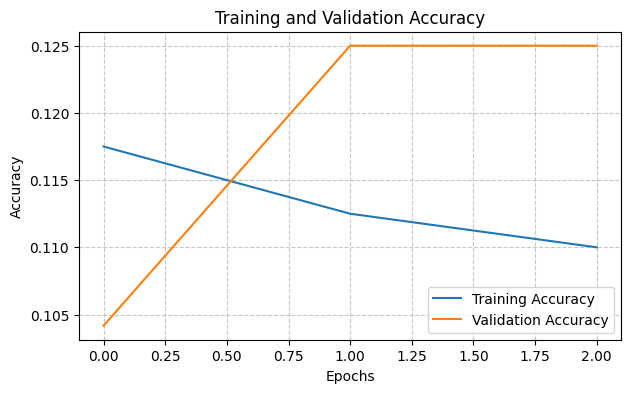

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot((epochs ), history.history['accuracy'], label='Training Accuracy')
plt.plot((epochs ), history.history['val_accuracy'], label='Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

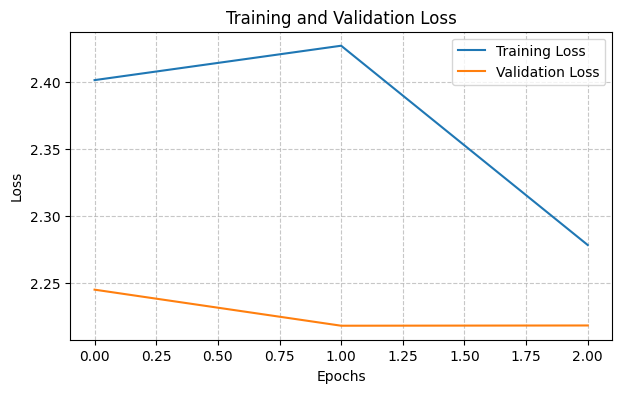

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
        

In [ ]:
score = model.evaluate(validation_generator ,verbose=1)
print('Test Loss:', score[0])
print('Test accuracy:', score[1]*100)

3/3 [==============================] - 8s 2s/step - loss: 2.2184 - accuracy: 0.1250
Test Loss: 2.218437433242798
Test accuracy: 12.5


In [ ]:
import numpy as np
from sklearn.metrics import classification_report


pred = model.predict(validation_generator)

# Convert the predicted probabilities to class labels
predicted_labels = np.argmax(pred, axis=1)

# Get the true labels from the validation generator
true_labels = validation_generator.classes

# Get class labels
class_labels = list(validation_generator.class_indices.keys())

# Compute the classification report with zero_division parameter set to 'warn'
report = classification_report(true_labels, predicted_labels, target_names=class_labels, zero_division=1)

print("Classification Report:")
print(report)


3/3 [==============================] - 9s 2s/step
Classification Report:
              precision    recall  f1-score   support

        Bush       1.00      0.00      0.00        12
       Ghoti       1.00      0.00      0.00        10
       Hedge       1.00      0.00      0.00        12
    KataBash       1.00      0.00      0.00        10
        Lota       1.00      0.00      0.00        11
         Ora       1.00      0.00      0.00        12
    Sinekais       0.12      1.00      0.22        12
       Sorno       1.00      0.00      0.00         6
       Vutum       1.00      0.00      0.00        11

    accuracy                           0.12        96
   macro avg       0.90      0.11      0.02        96
weighted avg       0.89      0.12      0.03        96



<Figure size 1200x1200 with 0 Axes>

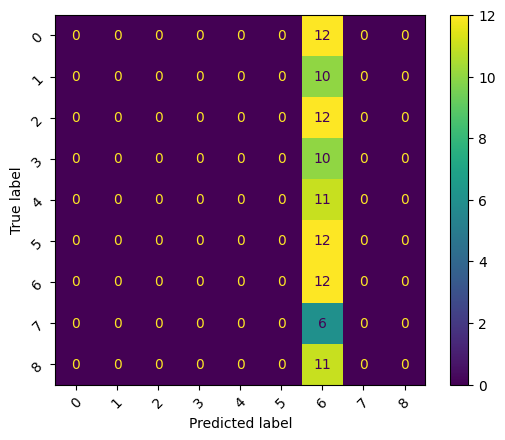

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix with adjusted figure size
plt.figure(figsize=(12, 12))  # Adjust the figure size as needed
disp.plot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.yticks(rotation=45)  # Rotate y-axis labels for better readability
plt.show()


In [ ]:
# target_names = []
# y_pred = model.predict(validation_generator).argmax(axis=1)
# for key in validation_generator.class_indices:
#     target_names.append(key)

# #print(target_names)

# from sklearn.metrics import classification_report

# # Compute the classification report with zero_division parameter set to 'warn'
# report = classification_report(validation_generator.classes, y_pred, target_names=target_names, zero_division=1)

# print('Classification Report:')
# print(report)
